<a href="https://colab.research.google.com/github/tanusreemajumder/Skill-Morph-Assignments/blob/main/assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/cybersecurity_intrusion_data.csv')

In [6]:
print("--- Task 1: Data Inspection ---")
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


--- Task 1: Data Inspection ---
Dataset Shape: (9537, 11)

Missing Values:
 session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [8]:
print(df.columns.tolist())

['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


In [18]:
target_col = 'attack_detected'
print(f"\nClass Distribution ({target_col}):\n", df[target_col].value_counts())


Class Distribution (attack_detected):
 attack_detected
0    5273
1    4264
Name: count, dtype: int64


In [17]:
# 1. Drop irrelevant columns (e.g., session_id string identifier)
if 'session_id' in df.columns:
    df = df.drop(columns=['session_id'])

In [19]:
# 2. Convert categorical columns to numeric using One-Hot Encoding
categorical_cols = ['protocol_type', 'encryption_used', 'browser_type']
existing_cat_cols = [c for c in categorical_cols if c in df.columns]
df = pd.get_dummies(df, columns=existing_cat_cols, dummy_na=False, drop_first=True)

In [20]:
# 3. Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

In [21]:
# 4. Fill any missing numerical values with median
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

In [22]:
# 5. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
# 6. Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

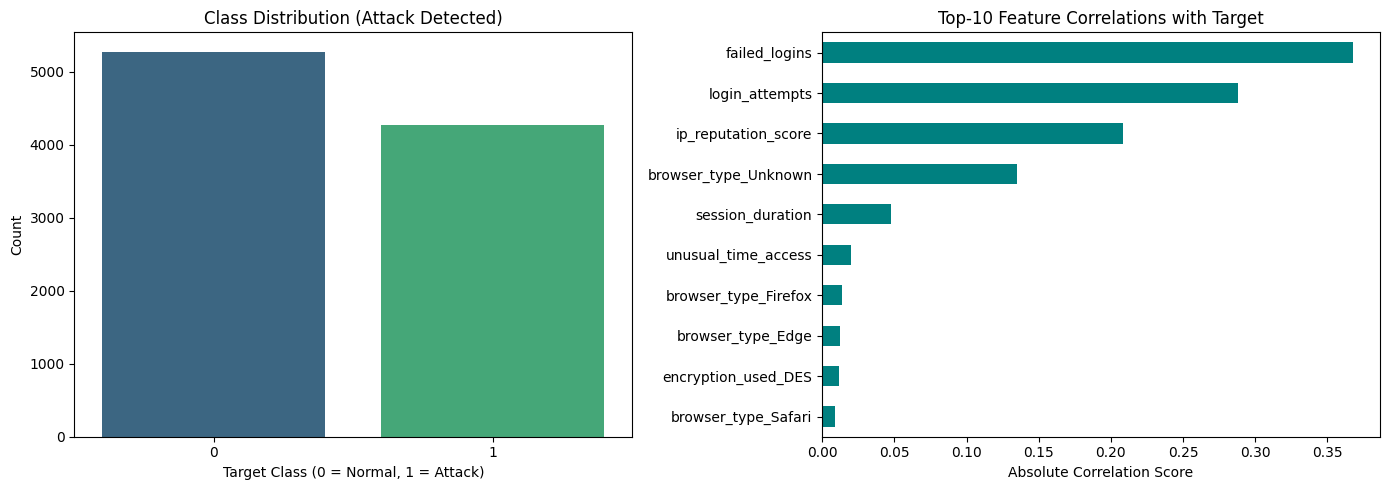

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1. Bar chart of class distribution
sns.countplot(x=y, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution (Attack Detected)')
axes[0].set_xlabel('Target Class (0 = Normal, 1 = Attack)')
axes[0].set_ylabel('Count')
# 2. Top-10 feature correlations with target
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
correlations = X_train_scaled_df.apply(lambda col: col.corr(y_train.reset_index(drop=True))).abs()
top_10_corr = correlations.nlargest(10)

top_10_corr.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top-10 Feature Correlations with Target')
axes[1].set_xlabel('Absolute Correlation Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [27]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy (%)': f"{acc * 100:.2f}%",
        'Precision (%)': f"{prec * 100:.2f}%",
        'Recall (%)': f"{rec * 100:.2f}%",
        'F1-Score (%)': f"{f1 * 100:.2f}%"
    })

results_df = pd.DataFrame(results)
print("\n--- Task 4: Model Comparison ---")
print(results_df.to_string(index=False))


--- Task 4: Model Comparison ---
              Model Accuracy (%) Precision (%) Recall (%) F1-Score (%)
      Decision Tree       81.45%        81.44%     81.45%       81.44%
          KNN (k=5)       79.14%        80.37%     79.14%       78.57%
Logistic Regression       72.85%        72.77%     72.85%       72.67%



--- Task 5: Decision Tree Depth Tuning ---
max_depth Accuracy (%)
        3       86.43%
        5       88.42%
       10       88.05%
       15       86.90%
       20       84.33%
     None       81.45%


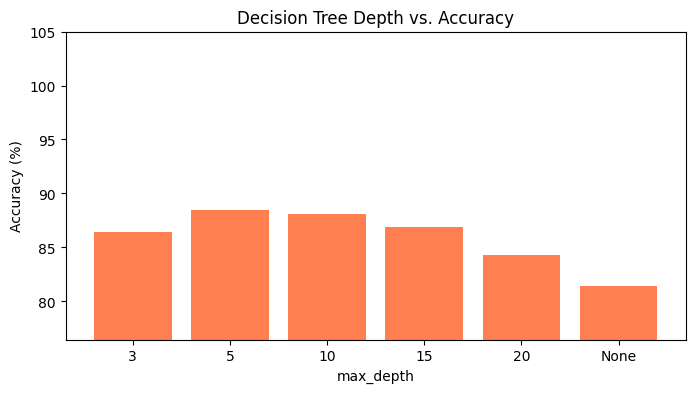

In [28]:
depths = [3, 5, 10, 15, 20, None]
depth_results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    y_pred = dt.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    depth_results.append({
        'max_depth': str(d),
        'Accuracy (%)': f"{acc * 100:.2f}%"
    })

depth_df = pd.DataFrame(depth_results)
print("\n--- Task 5: Decision Tree Depth Tuning ---")
print(depth_df.to_string(index=False))

# Bar Chart for Depth Tuning
plt.figure(figsize=(8, 4))
acc_numeric = [float(val.rstrip('%')) for val in depth_df['Accuracy (%)']]
plt.bar(depth_df['max_depth'], acc_numeric, color='coral')
plt.title('Decision Tree Depth vs. Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy (%)')
plt.ylim(min(acc_numeric) - 5, 105)
plt.show()


--- Task 6: Detailed Classification Reports ---

================ Decision Tree ================

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1055
           1       0.79      0.79      0.79       853

    accuracy                           0.81      1908
   macro avg       0.81      0.81      0.81      1908
weighted avg       0.81      0.81      0.81      1908


================ KNN (k=5) ================

              precision    recall  f1-score   support

           0       0.76      0.92      0.83      1055
           1       0.86      0.64      0.73       853

    accuracy                           0.79      1908
   macro avg       0.81      0.78      0.78      1908
weighted avg       0.80      0.79      0.79      1908


================ Logistic Regression ================

              precision    recall  f1-score   support

           0       0.74      0.79      0.76      1055
           1       0.72      0.65   

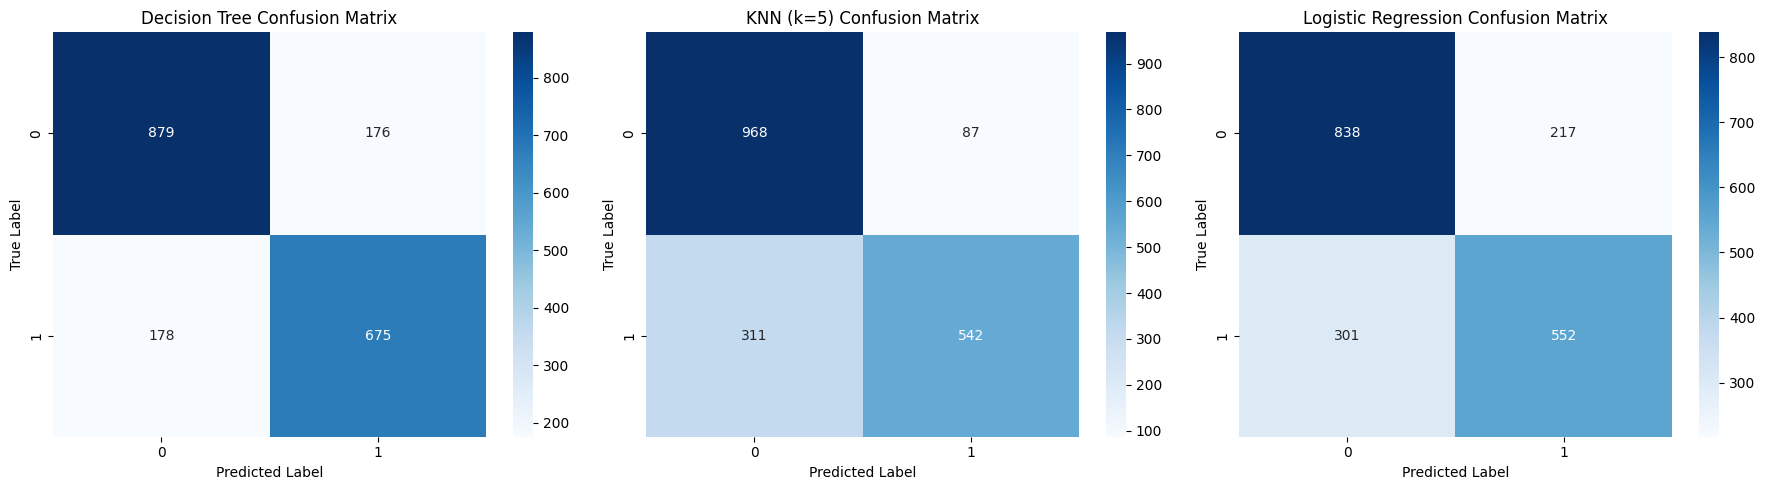

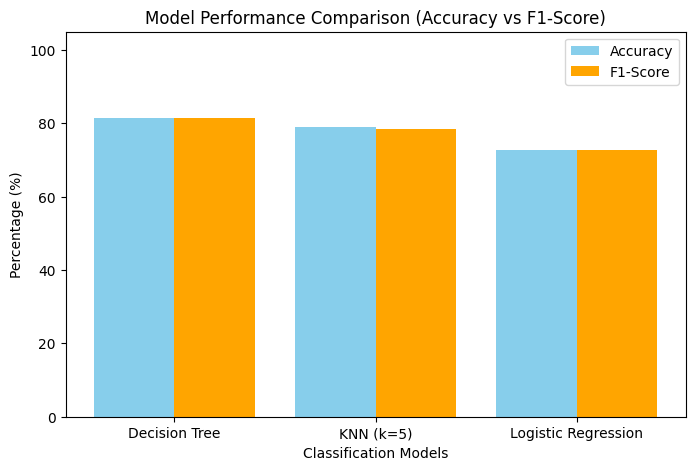

In [29]:
# 1. Classification Reports
print("\n--- Task 6: Detailed Classification Reports ---")
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n================ {name} ================\n")
    print(classification_report(y_test, y_pred))

# 2. 1x3 Confusion Matrix Grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# 3. Model Comparison Bar Chart
metrics_plot_df = pd.DataFrame(results)
metrics_plot_df['Accuracy'] = metrics_plot_df['Accuracy (%)'].str.rstrip('%').astype(float)
metrics_plot_df['F1-Score'] = metrics_plot_df['F1-Score (%)'].str.rstrip('%').astype(float)

plt.figure(figsize=(8, 5))
x_axis = np.arange(len(metrics_plot_df['Model']))
plt.bar(x_axis - 0.2, metrics_plot_df['Accuracy'], 0.4, label='Accuracy', color='skyblue')
plt.bar(x_axis + 0.2, metrics_plot_df['F1-Score'], 0.4, label='F1-Score', color='orange')

plt.xticks(x_axis, metrics_plot_df['Model'])
plt.xlabel('Classification Models')
plt.ylabel('Percentage (%)')
plt.title('Model Performance Comparison (Accuracy vs F1-Score)')
plt.legend()
plt.ylim(0, 105)
plt.show()